# DataCo Inventory Analytics — working notebook

**Business question:** Across this catalog, where is working capital trapped in slow-moving inventory, and how should reorder policies change to free cash without dropping below a 95% service level?

Flow: raw CSV → audit (this section) → DuckDB SQL aggregation → pandas per-SKU stats → 4 layers → `outputs/sku_metrics.csv`.

---
## Audit the raw data

Goal: confirm the data is trustworthy before aggregating. Row count, date range, nulls on the columns every downstream metric depends on, and a first look at demand shape.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = "../data/DataCoSupplyChainDataset.csv"

# latin-1: the file has non-UTF-8 bytes and errors under the default encoding
raw = pd.read_csv(RAW, encoding="latin-1")
print(f"rows: {len(raw):,}   columns: {raw.shape[1]}")
raw.head(3)

rows: 180,519   columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [2]:
# The columns every downstream metric depends on.
KEY_COLS = [
    "Product Card Id",              # the SKU key
    "Order Item Quantity",          # demand
    "order date (DateOrders)",      # time axis
    "Product Price",                # value / ABC / EOQ
    "Days for shipping (real)",     # lead time -> safety stock
]

raw[KEY_COLS].info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Product Card Id           180519 non-null  int64  
 1   Order Item Quantity       180519 non-null  int64  
 2   order date (DateOrders)   180519 non-null  str    
 3   Product Price             180519 non-null  float64
 4   Days for shipping (real)  180519 non-null  int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 9.4 MB


In [3]:
# Null check on the key columns
nulls = raw[KEY_COLS].isna().sum()
print("nulls in key columns:")
print(nulls)
assert nulls.sum() == 0, "key columns contain nulls — handle before aggregating"

nulls in key columns:
Product Card Id             0
Order Item Quantity         0
order date (DateOrders)     0
Product Price               0
Days for shipping (real)    0
dtype: int64


In [4]:
# Date range. Source format looks like  M/D/YYYY H:MM  e.g. 1/31/2018 22:56
order_date = pd.to_datetime(raw["order date (DateOrders)"], format="%m/%d/%Y %H:%M")
print("earliest order:", order_date.min())
print("latest order:  ", order_date.max())
print("span (months): ", (order_date.max().to_period("M") - order_date.min().to_period("M")).n + 1)
print("unparsed dates:", order_date.isna().sum())

earliest order: 2015-01-01 00:00:00
latest order:   2018-01-31 23:38:00
span (months):  37
unparsed dates: 0


In [5]:
# Scale of the catalog + basic distributions
print("distinct SKUs (Product Card Id):", raw["Product Card Id"].nunique())
print()
print(raw["Order Item Quantity"].describe())
print()
print(raw["Product Price"].describe())
print()
print("Days for shipping (real):")
print(raw["Days for shipping (real)"].describe())

distinct SKUs (Product Card Id): 118

count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: Order Item Quantity, dtype: float64

count    180519.000000
mean        141.232550
std         139.732492
min           9.990000
25%          50.000000
50%          59.990002
75%         199.990005
max        1999.989990
Name: Product Price, dtype: float64

Days for shipping (real):
count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Days for shipping (real), dtype: float64


top 10 SKUs by total units:
Product Card Id  Product Name                                 
365              Perfect Fitness Perfect Rip Deck                 73698
502              Nike Men's Dri-FIT Victory Golf Polo             62956
1014             O'Brien Men's Neoprene Life Vest                 57803
191              Nike Men's Free 5.0+ Running Shoe                36680
627              Under Armour Girls' Toddler Spine Surge Runni    31735
403              Nike Men's CJ Elite 2 TD Football Cleat          22246
1004             Field & Stream Sportsman 16 Gun Fire Safe        17325
1073             Pelican Sunstream 100 Kayak                      15500
957              Diamondback Women's Serene Classic Comfort Bi    13729
977              ENO Atlas Hammock Straps                           998
Name: Order Item Quantity, dtype: int64


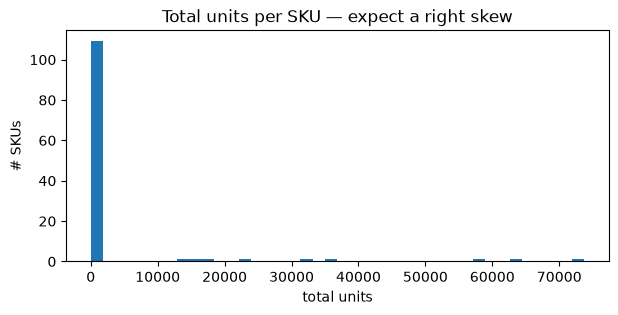

In [6]:
# Do the top sellers make sense, and is total demand right-skewed?
demand_by_sku = (
    raw.groupby(["Product Card Id", "Product Name"])["Order Item Quantity"]
    .sum()
    .sort_values(ascending=False)
)
print("top 10 SKUs by total units:")
print(demand_by_sku.head(10))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(demand_by_sku.values, bins=40)
ax.set_title("Total units per SKU — expect a right skew")
ax.set_xlabel("total units")
ax.set_ylabel("# SKUs")
plt.show()

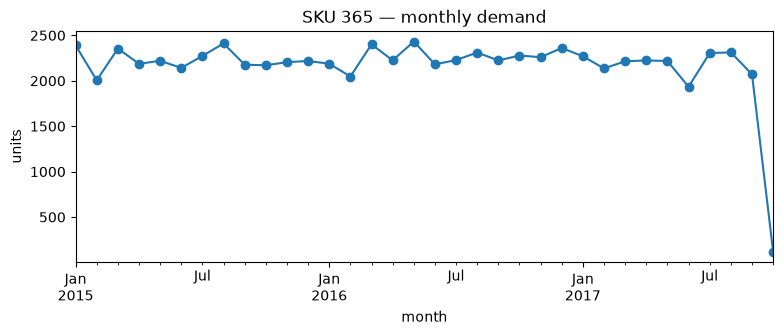

In [7]:
# One SKU's monthly demand series (spot-check the time axis behaves)
top_sku = demand_by_sku.index[0][0]
one = raw.loc[raw["Product Card Id"] == top_sku].copy()
one["month"] = pd.to_datetime(one["order date (DateOrders)"], format="%m/%d/%Y %H:%M").dt.to_period("M")
monthly = one.groupby("month")["Order Item Quantity"].sum()

fig, ax = plt.subplots(figsize=(9, 3))
monthly.plot(ax=ax, marker="o")
ax.set_title(f"SKU {top_sku} — monthly demand")
ax.set_ylabel("units")
plt.show()

### Audit findings

- **Rows / columns:** 180,519 rows × 53 columns
- **Date range:** 2015-01-01 to 2018-01-31 (37 months)
- **Distinct SKUs:** 118
- **Nulls in key columns:** none — 0 across all 5 (`Product Card Id`,
  `Order Item Quantity`, `order date (DateOrders)`, `Product Price`,
  `Days for shipping (real)`)
- **Demand shape:** right-skewed — a small number of SKUs carry most of the
  unit volume. This is the ABC/Pareto result already visible in the raw data.
- **Anything odd:**
  - `Order Item Quantity` ranges 1–5, no zeros or negatives — clean.
  - `Product Price` ranges $9.99–$1999.99, no zeros — clean.
  - `Days for shipping (real)` ranges only 0–6 days — a very tight spread, so
    σ(lead time) will be small. Safety stock will be driven mostly by *demand*
    variability, not lead-time variability.
  - ~19% of orders (33,784) have a negative `Benefit per order`. Kept on purpose
    — it's the signal for prioritising which SKUs to fix first.
  - Only ~1,818 SKU-months are populated out of a possible 118 × 37 ≈ 4,366, so
    many SKUs have months with zero sales. **Decision needed** before computing
    σ(demand): treat missing months as zero-demand, or ignore them? This changes
    the safety-stock numbers.


---
## Build the per-SKU demand profile

`src/extract.py` gave us demand at **SKU x month** grain. The four analytical layers
need **one row per SKU** with demand and lead-time statistics already computed.

Steps:
1. read the two aggregated CSVs
2. for each SKU, rebuild its monthly series between its first and last sale month,
   filling gap months with **0** (a month with no orders is demand = 0, not missing)
3. collapse that padded series to mean / std of monthly demand
4. flag SKUs with too little history for a trustworthy std
5. join the per-SKU lead-time stats
6. save `outputs/sku_demand_profile.csv` — the per-SKU deliverable


In [8]:
import numpy as np

demand_m = pd.read_csv("../outputs/demand_by_sku_month.csv", parse_dates=["month"])
leadtime = pd.read_csv("../outputs/leadtime_by_sku.csv")

print("demand_by_sku_month:", demand_m.shape)
print("leadtime_by_sku:    ", leadtime.shape)
demand_m.head()

demand_by_sku_month: (1818, 6)
leadtime_by_sku:     (118, 4)


,sku,product_name,month,units,order_lines,avg_price
0,19,Nike Men's Fingertrap Max Training Shoe,2017-04-01,2.0,2,124.989998
1,19,Nike Men's Fingertrap Max Training Shoe,2017-05-01,13.0,13,124.989998
2,19,Nike Men's Fingertrap Max Training Shoe,2017-06-01,13.0,13,124.989998
3,19,Nike Men's Fingertrap Max Training Shoe,2017-07-01,15.0,15,124.989998
4,19,Nike Men's Fingertrap Max Training Shoe,2017-08-01,17.0,17,124.989998


In [9]:
# Below this many months of history, std(monthly demand) is not trustworthy.
MIN_MONTHS = 6


def sku_profile(g):
    """Collapse one SKU's monthly rows to a single profile row.

    Gap months between the SKU's first and last sale are filled with 0 so the
    std reflects the real on/off lumpiness of demand. Months before the first
    sale / after the last are NOT added (the product did not exist then)."""
    s = g.set_index("month")["units"].sort_index()
    full = pd.period_range(s.index.min().to_period("M"),
                           s.index.max().to_period("M"), freq="M").to_timestamp()
    units = s.reindex(full, fill_value=0)
    return pd.Series({
        "product_name": g["product_name"].iloc[0],
        "avg_price": g["avg_price"].mean(),
        "n_months": len(units),
        "total_units": units.sum(),
        "mean_monthly_demand": units.mean(),
        "std_monthly_demand": units.std(ddof=1),   # NaN when n_months == 1
    })


profile = (
    demand_m.groupby("sku", group_keys=True)
    .apply(sku_profile, include_groups=False)
    .reset_index()
)
profile["insufficient_history"] = profile["n_months"] < MIN_MONTHS
profile.head()

,sku,product_name,avg_price,n_months,total_units,mean_monthly_demand,std_monthly_demand,insufficient_history
0,19,Nike Men's Fingertrap Max Training Shoe,124.989998,6,64.0,10.666667,6.153590,False
1,24,Elevation Training Mask 2.0,79.989998,6,231.0,38.500000,23.939507,False
2,35,adidas Brazuca 2014 Official Match Ball,159.990006,6,65.0,10.833333,4.622409,False
3,37,adidas Kids' F5 Messi FG Soccer Cleat,34.990002,28,781.0,27.892857,11.911213,False
4,44,adidas Men's F10 Messi TRX FG Soccer Cleat,59.990002,28,939.0,33.535714,11.026843,False


In [10]:
sku_demand_profile = profile.merge(
    leadtime[["sku", "avg_lead_time_days", "std_lead_time_days"]],
    on="sku", how="left",
)

out_path = "../outputs/sku_demand_profile.csv"
sku_demand_profile.to_csv(out_path, index=False)

print("saved", sku_demand_profile.shape, "->", out_path)
print()
print("insufficient_history (n_months <", MIN_MONTHS, "):")
print(sku_demand_profile["insufficient_history"].value_counts())
print()
print("rows with NaN std_monthly_demand (1-month SKUs):",
      sku_demand_profile["std_monthly_demand"].isna().sum())
sku_demand_profile.sort_values("total_units", ascending=False).head(10)

saved (118, 10) -> ../outputs/sku_demand_profile.csv

insufficient_history (n_months < 6 ):
insufficient_history
False    85
True     33
Name: count, dtype: int64

rows with NaN std_monthly_demand (1-month SKUs): 9


,sku,product_name,avg_price,n_months,total_units,mean_monthly_demand,std_monthly_demand,insufficient_history,avg_lead_time_days,std_lead_time_days
35,365,Perfect Fitness Perfect Rip Deck,59.990002,34,73698.0,2167.588235,378.737385,False,3.506384,1.631457
37,502,Nike Men's Dri-FIT Victory Golf Polo,50.000000,34,62956.0,1851.647059,329.715937,False,3.484716,1.620296
97,1014,O'Brien Men's Neoprene Life Vest,49.980000,34,57803.0,1700.088235,306.661729,False,3.495751,1.627167
15,191,Nike Men's Free 5.0+ Running Shoe,99.989998,34,36680.0,1078.823529,200.050519,False,3.493960,1.620662
44,627,Under Armour Girls' Toddler Spine Surge Runni,39.990002,34,31735.0,933.382353,172.346904,False,3.494584,1.629719
36,403,Nike Men's CJ Elite 2 TD Football Cleat,129.990006,34,22246.0,654.294118,114.856044,False,3.501259,1.617746
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,34,17325.0,509.558824,90.182371,False,3.502049,1.614683
99,1073,Pelican Sunstream 100 Kayak,199.990006,34,15500.0,455.882353,80.602566,False,3.483032,1.623083
92,957,Diamondback Women's Serene Classic Comfort Bi,299.980011,34,13729.0,403.794118,71.108871,False,3.498215,1.626472
93,977,ENO Atlas Hammock Straps,29.990000,28,998.0,35.642857,10.705534,False,3.455108,1.651368


### Modelling choices recorded here

- **Gap months = 0 demand.** Filled only *between* each SKU's first and last sale.
  On this data that touches ~10 SKUs by 1 month each, so the numeric effect is
  small, but it is the defensible method and matters more once the catalog grows.
- **`MIN_MONTHS = 6`.** 33 of 118 SKUs fall below this and are flagged
  `insufficient_history`; 9 of those have only one month of sales, so their
  `std_monthly_demand` is `NaN`. In the safety-stock layer these SKUs get a class-level fallback
  sigma rather than a per-SKU one, and are kept out of the headline
  trapped-cash number.
- **Stockout censoring (known limitation).** A zero-sales month could mean
  "no demand" or "we were out of stock". The dataset has no on-hand column, so
  the two cannot be told apart; zeros are treated as true zero demand.

Deliverable: `outputs/sku_demand_profile.csv`.


---
# The analytical layers

Each layer is a function in `src/inventory.py`; the notebook calls them and
inspects the result. Assumptions (`S`, `H_RATE`, service levels) live at the top
of that module.

## Layer 1 — implied turnover, days-of-supply, velocity tier

No on-hand column exists, so average inventory is derived from the sawtooth
cycle-stock model: average cycle stock = EOQ / 2. Because that proxy assumes
cost-optimal ordering, the turns figure is a **best-case benchmark** — it ranks
SKUs by relative velocity, it does not prove overstocking. Output is a relative
`velocity_tier` (Slow / Medium / Fast by tercile), not an absolute verdict.


In [11]:
import sys
sys.path.insert(0, "..")   # so "src" is importable when running from notebooks/

from src.inventory import annualize_demand, layer1_turnover, S, H_RATE

profile = pd.read_csv("../outputs/sku_demand_profile.csv")

l1 = layer1_turnover(annualize_demand(profile))
print(f"assumptions in use:  S = ${S:.0f} / order,  H_RATE = {H_RATE:.0%} of price / year")
l1[["sku", "product_name", "avg_price", "annual_demand",
    "implied_eoq", "implied_turns", "implied_days_of_supply",
    "velocity_tier", "slow_mover"]].head()

assumptions in use:  S = $75 / order,  H_RATE = 25% of price / year


,sku,product_name,avg_price,annual_demand,implied_eoq,implied_turns,implied_days_of_supply,velocity_tier,slow_mover
0,19,Nike Men's Fingertrap Max Training Shoe,124.989998,128.000000,24.788085,10.327542,35.342387,Slow,True
1,24,Elevation Training Mask 2.0,79.989998,462.000000,58.867931,15.696152,23.254107,Medium,False
2,35,adidas Brazuca 2014 Official Match Ball,159.990006,130.000000,22.080092,11.775313,30.997052,Medium,False
3,37,adidas Kids' F5 Messi FG Soccer Cleat,34.990002,334.714286,75.760140,8.836158,41.307545,Slow,True
4,44,adidas Men's F10 Messi TRX FG Soccer Cleat,59.990002,402.428571,63.442544,12.686394,28.770980,Medium,False


In [12]:
# What each velocity tier looks like
tier_summary = (
    l1.groupby("velocity_tier", observed=True)
      .agg(skus=("sku", "size"),
           median_turns=("implied_turns", "median"),
           median_days_of_supply=("implied_days_of_supply", "median"),
           median_annual_value=("annual_demand_value", "median"),
           total_annual_value=("annual_demand_value", "sum"))
      .round(0)
)
print(tier_summary)
print()
print("slowest 8 SKUs by implied turns:")
print(l1.sort_values("implied_turns")
        [["sku", "product_name", "avg_price", "annual_demand",
          "implied_turns", "implied_days_of_supply"]]
        .head(8).to_string(index=False))

               skus  median_turns  median_days_of_supply  median_annual_value  \
velocity_tier                                                                   
Slow             40           8.0                   45.0               9693.0   
Medium           39          13.0                   28.0              26353.0   
Fast             39          46.0                    8.0             317582.0   

               total_annual_value  
velocity_tier                      
Slow                     410267.0  
Medium                  1063121.0  
Fast                   23838401.0  

slowest 8 SKUs by implied turns:
 sku                         product_name  avg_price  annual_demand  implied_turns  implied_days_of_supply
 775              Clicgear 8.0 Shoe Brush       9.99     380.571429       5.034487               72.499943
 792        Hirzl Men's Hybrid Golf Glove      14.99     370.285714       6.083082               60.002480
 793      Hirzl Women's Hybrid Golf Glove      14.99     38

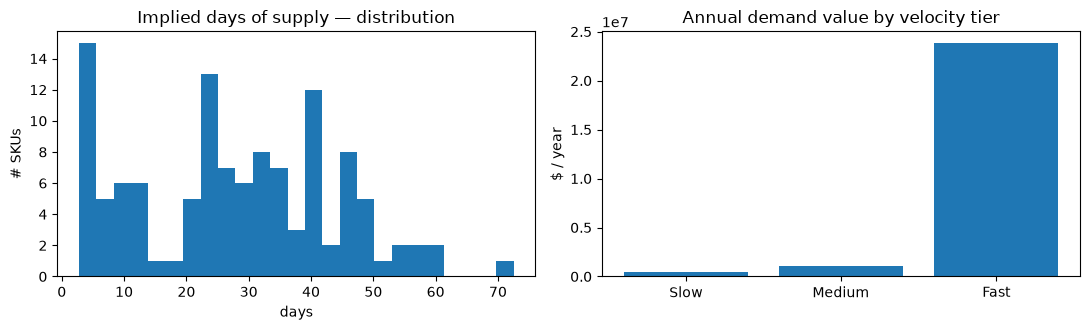

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))

ax[0].hist(l1["implied_days_of_supply"], bins=25)
ax[0].set_title("Implied days of supply — distribution")
ax[0].set_xlabel("days")
ax[0].set_ylabel("# SKUs")

order = ["Slow", "Medium", "Fast"]
ax[1].bar(order, [l1.loc[l1.velocity_tier == t, "annual_demand_value"].sum() for t in order])
ax[1].set_title("Annual demand value by velocity tier")
ax[1].set_ylabel("$ / year")

plt.tight_layout()
plt.show()

### What Layer 1 says

- Split into 40 Slow / 39 Medium / 39 Fast SKUs by tercile of implied turns.
- The **Slow tier** is low-price, low-volume accessories: median ~45 days of
  supply and only ~$10k annual demand value each. The **Fast tier** moves
  ~$300k+ each and clears stock in ~8 days.
- `slow_mover = velocity_tier == "Slow"` — carried forward; Layer 5 crosses it
  against ABC class to find where buffer cash is misallocated.
- **Caveat repeated:** turns here assume EOQ ordering, so they are a floor on how
  well stock *could* move, not a measurement of how it actually moves.
